In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [211]:
# section 1

In [212]:
df=pd.read_csv("E:\\Python Training\\streamlit ui\\indian_ecommerce_pricing_revenue_growth_36_months.csv")

In [213]:
df.head(10)

,order_id,order_date,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,units_sold,revenue,sales_event,competition_intensity,inventory_pressure
0,ORD0000001,2023-01-31,West Bengal,East,Fashion,Mass,Male,28,1810.89,65.00,633.81,29,18380.49,Normal,Medium,High
1,ORD0000002,2023-01-31,Gujarat,West,Sports & Fitness,Mass,Male,19,5678.15,50.83,2791.95,67,187060.65,Normal,Medium,High
2,ORD0000003,2023-01-31,Delhi NCR,North,Grocery Essentials,Mass,Male,25,169.98,35.26,110.05,57,6272.85,Normal,Medium,Low
3,ORD0000004,2023-01-31,Madhya Pradesh,Central,Footwear,Mass,Female,30,3244.91,61.94,1235.01,55,67925.55,Normal,High,High
4,ORD0000005,2023-01-31,Haryana,North,Fashion,Premium,Female,33,697.44,48.27,360.79,29,10462.91,Festival,Medium,High
5,ORD0000006,2023-01-31,Punjab,North,Grocery Essentials,Mass,Female,19,100.55,65.00,35.19,16,563.04,Festival,High,High
6,ORD0000007,2023-01-31,Delhi NCR,North,Home & Living,Mass,Female,47,2382.06,46.86,1265.83,34,43038.22,Normal,Medium,High
7,ORD0000008,2023-01-31,West Bengal,East,Fashion,Mass,Male,23,580.72,46.86,308.59,27,8331.93,Normal,Medium,High
8,ORD0000009,2023-01-31,West Bengal,East,Grocery Essentials,Mass,Male,45,132.67,65.00,46.43,52,2414.36,Festival,High,Low
9,ORD0000010,2023-01-31,Gujarat,West,Grocery Essentials,Premium,Male,40,419.25,40.48,249.54,44,10979.76,Normal,Medium,High


In [214]:
df.shape

(30600, 16)

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30600 non-null  object 
 1   order_date             30600 non-null  object 
 2   state                  30600 non-null  object 
 3   zone                   30600 non-null  object 
 4   category               30600 non-null  object 
 5   brand_type             30600 non-null  object 
 6   customer_gender        30600 non-null  object 
 7   customer_age           30600 non-null  int64  
 8   base_price             30600 non-null  float64
 9   discount_percent       30600 non-null  float64
 10  final_price            30600 non-null  float64
 11  units_sold             30600 non-null  int64  
 12  revenue                30600 non-null  float64
 13  sales_event            30600 non-null  object 
 14  competition_intensity  30600 non-null  object 
 15  in

In [216]:
df.isna().sum()

order_id                 0
order_date               0
state                    0
zone                     0
category                 0
brand_type               0
customer_gender          0
customer_age             0
base_price               0
discount_percent         0
final_price              0
units_sold               0
revenue                  0
sales_event              0
competition_intensity    0
inventory_pressure       0
dtype: int64

In [217]:
df["datetime"]=df.order_date

In [218]:
df.drop("order_date",axis=1,inplace=True)

In [219]:
df[["customer_age","datetime"]]

,customer_age,datetime
0,28,2023-01-31
1,19,2023-01-31
2,25,2023-01-31
3,30,2023-01-31
4,33,2023-01-31
...,...,...
30595,54,2025-12-31
30596,18,2025-12-31
30597,58,2025-12-31
30598,23,2025-12-31


In [220]:
df.customer_age.dtype

dtype('int64')

In [221]:
df.datetime.dtype

dtype('O')

In [222]:
df["year"]=df.datetime.str.split("-").str[0]
df["month"]=df.datetime.str.split("-").str[1].str.strip()

In [223]:
df.columns

Index(['order_id', 'state', 'zone', 'category', 'brand_type',
       'customer_gender', 'customer_age', 'base_price', 'discount_percent',
       'final_price', 'units_sold', 'revenue', 'sales_event',
       'competition_intensity', 'inventory_pressure', 'datetime', 'year',
       'month'],
      dtype='object')

In [224]:
df["discount_amount"]=df["base_price"]-df["final_price"]
df["revenue_check"]=df["final_price"]*df["units_sold"]

In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               30600 non-null  object 
 1   state                  30600 non-null  object 
 2   zone                   30600 non-null  object 
 3   category               30600 non-null  object 
 4   brand_type             30600 non-null  object 
 5   customer_gender        30600 non-null  object 
 6   customer_age           30600 non-null  int64  
 7   base_price             30600 non-null  float64
 8   discount_percent       30600 non-null  float64
 9   final_price            30600 non-null  float64
 10  units_sold             30600 non-null  int64  
 11  revenue                30600 non-null  float64
 12  sales_event            30600 non-null  object 
 13  competition_intensity  30600 non-null  object 
 14  inventory_pressure     30600 non-null  object 
 15  da

In [226]:
df["compare"]=df["revenue_check"] == df["revenue"]

In [227]:
df["compare"].value_counts()

compare
True     23260
False     7340
Name: count, dtype: int64

In [228]:
#section 2

In [229]:
df.columns

Index(['order_id', 'state', 'zone', 'category', 'brand_type',
       'customer_gender', 'customer_age', 'base_price', 'discount_percent',
       'final_price', 'units_sold', 'revenue', 'sales_event',
       'competition_intensity', 'inventory_pressure', 'datetime', 'year',
       'month', 'discount_amount', 'revenue_check', 'compare'],
      dtype='object')

In [230]:
df.revenue.sum()

np.float64(2174510366.9900002)

In [231]:
df["revenue"].mean()

np.float64(71062.43029379085)

In [232]:
df

,order_id,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,...,revenue,sales_event,competition_intensity,inventory_pressure,datetime,year,month,discount_amount,revenue_check,compare
0,ORD0000001,West Bengal,East,Fashion,Mass,Male,28,1810.89,65.00,633.81,...,18380.49,Normal,Medium,High,2023-01-31,2023,01,1177.08,18380.49,False
1,ORD0000002,Gujarat,West,Sports & Fitness,Mass,Male,19,5678.15,50.83,2791.95,...,187060.65,Normal,Medium,High,2023-01-31,2023,01,2886.20,187060.65,True
2,ORD0000003,Delhi NCR,North,Grocery Essentials,Mass,Male,25,169.98,35.26,110.05,...,6272.85,Normal,Medium,Low,2023-01-31,2023,01,59.93,6272.85,False
3,ORD0000004,Madhya Pradesh,Central,Footwear,Mass,Female,30,3244.91,61.94,1235.01,...,67925.55,Normal,High,High,2023-01-31,2023,01,2009.90,67925.55,True
4,ORD0000005,Haryana,North,Fashion,Premium,Female,33,697.44,48.27,360.79,...,10462.91,Festival,Medium,High,2023-01-31,2023,01,336.65,10462.91,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30595,ORD0030596,Uttar Pradesh,North,Premium Lifestyle,Mass,Male,54,12463.98,38.99,7604.27,...,83646.97,Normal,Medium,Low,2025-12-31,2025,12,4859.71,83646.97,True
30596,ORD0030597,Haryana,North,Footwear,Premium,Male,18,3974.58,39.35,2410.58,...,48211.60,Festival,Low,Low,2025-12-31,2025,12,1564.00,48211.60,True
30597,ORD0030598,Odisha,East,Footwear,Mass,Female,58,3020.42,65.00,1057.15,...,62371.85,Festival,High,Low,2025-12-31,2025,12,1963.27,62371.85,False
30598,ORD0030599,West Bengal,East,Sports & Fitness,Mass,Female,23,1212.05,12.35,1062.36,...,8498.88,Normal,Medium,Low,2025-12-31,2025,12,149.69,8498.88,True


In [233]:
df.columns

Index(['order_id', 'state', 'zone', 'category', 'brand_type',
       'customer_gender', 'customer_age', 'base_price', 'discount_percent',
       'final_price', 'units_sold', 'revenue', 'sales_event',
       'competition_intensity', 'inventory_pressure', 'datetime', 'year',
       'month', 'discount_amount', 'revenue_check', 'compare'],
      dtype='object')

In [234]:
df["revenue"].mean()

np.float64(71062.43029379085)

In [235]:
df.groupby("category")["units_sold"].max()

category
Beauty & Personal Care    154
Electronics               154
Fashion                   142
Footwear                  161
Grocery Essentials        151
Home & Living             161
Premium Lifestyle         145
Sports & Fitness          144
Name: units_sold, dtype: int64

In [236]:
df.groupby("category")["revenue"].max()

category
Beauty & Personal Care    144441.35
Electronics               769141.20
Fashion                   237435.66
Footwear                  347410.56
Grocery Essentials         55943.22
Home & Living             392021.56
Premium Lifestyle         906141.04
Sports & Fitness          436159.06
Name: revenue, dtype: float64

In [237]:
df.groupby("state")["revenue"].sum()

state
Chhattisgarh      1.153489e+08
Delhi NCR         1.956911e+08
Gujarat           1.682156e+08
Haryana           1.572334e+08
Karnataka         1.887672e+08
Kerala            1.683534e+08
Madhya Pradesh    1.312256e+08
Maharashtra       1.894436e+08
Odisha            1.218676e+08
Punjab            1.586658e+08
Tamil Nadu        1.654015e+08
Telangana         1.669118e+08
Uttar Pradesh     1.249221e+08
West Bengal       1.224628e+08
Name: revenue, dtype: float64

In [238]:
df.groupby("zone")["revenue"].sum()

zone
Central    2.465746e+08
East       2.443304e+08
North      6.365123e+08
South      6.894339e+08
West       3.576592e+08
Name: revenue, dtype: float64

In [239]:
df.groupby("customer_gender")["revenue"].mean()

customer_gender
Female    71289.776466
Male      70836.033127
Name: revenue, dtype: float64

In [240]:
df.groupby("customer_age")["revenue"].mean()

customer_age
18    88756.511315
19    89994.368059
20    85100.491864
21    88284.041794
22    85466.915532
23    88888.123406
24    85163.932780
25    69141.905637
26    73557.547024
27    70184.785872
28    71355.649582
29    72659.344159
30    77381.223833
31    72802.476783
32    71358.784245
33    71723.636154
34    65723.039358
35    64093.729111
36    66721.800541
37    66866.464146
38    59734.609554
39    61335.979587
40    64482.210685
41    64027.556018
42    68187.390677
43    64221.169630
44    63113.917764
45    60897.600936
46    59330.111289
47    61447.158445
48    55046.224566
49    64744.324809
50    57313.053478
51    60909.531134
52    57472.883793
53    62258.497472
54    62122.426441
55    60700.846421
56    60418.998808
57    58136.532555
58    58290.940260
59    58327.459113
60    55787.290483
61    57171.109805
62    68468.815204
63    55434.920000
64    61202.411973
65    60095.922556
Name: revenue, dtype: float64

In [241]:
df[(df["customer_age"]>=18) & (df["customer_age"]<=25)]["revenue"].mean()

np.float64(85522.38299363058)

In [242]:
df[(df["customer_age"]>=26) & (df["customer_age"]<=35)]["revenue"].mean()

np.float64(71276.41520743596)

In [243]:
df[(df["customer_age"]>=36) & (df["customer_age"]<=45)]["revenue"].mean()

np.float64(64047.64096978801)

In [244]:
df[(df["customer_age"]>=46)]["revenue"].mean()

np.float64(59781.31782186346)

In [245]:
df.groupby("discount_percent")["revenue"].mean()

discount_percent
0.01      34136.150000
0.02      11843.000000
0.10       8383.680000
0.14      16782.740000
0.16      16564.640000
             ...      
64.96    136302.390000
64.97     73202.940000
64.98     56100.255000
64.99     80702.002500
65.00     67731.193458
Name: revenue, Length: 5976, dtype: float64

In [246]:
df.groupby("brand_type")["revenue"].sum()

brand_type
Mass       1.604407e+09
Premium    5.701032e+08
Name: revenue, dtype: float64

In [247]:
#section 3
df.columns

Index(['order_id', 'state', 'zone', 'category', 'brand_type',
       'customer_gender', 'customer_age', 'base_price', 'discount_percent',
       'final_price', 'units_sold', 'revenue', 'sales_event',
       'competition_intensity', 'inventory_pressure', 'datetime', 'year',
       'month', 'discount_amount', 'revenue_check', 'compare'],
      dtype='object')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Fashion'),
  Text(1, 0, 'Sports & Fitness'),
  Text(2, 0, 'Grocery Essentials'),
  Text(3, 0, 'Footwear'),
  Text(4, 0, 'Home & Living'),
  Text(5, 0, 'Beauty & Personal Care'),
  Text(6, 0, 'Electronics'),
  Text(7, 0, 'Premium Lifestyle')])

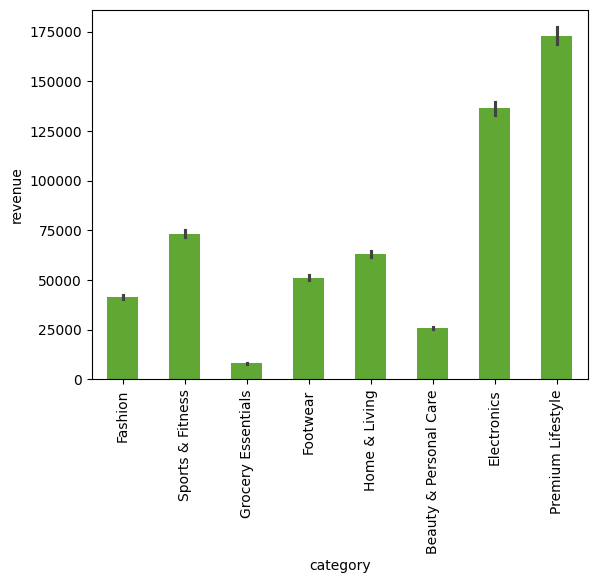

In [248]:
sns.barplot(data=df,x="category",y="revenue",width=0.5,color="#5BBC1F")
plt.xticks(rotation=90)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'East'),
  Text(1, 0, 'West'),
  Text(2, 0, 'North'),
  Text(3, 0, 'Central'),
  Text(4, 0, 'South')])

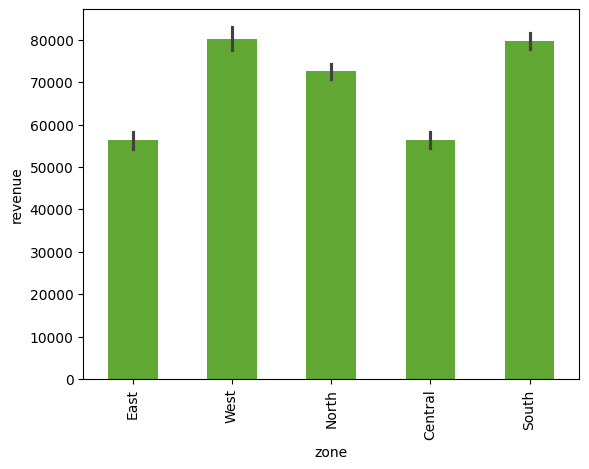

In [249]:
sns.barplot(data=df,x="zone",y="revenue",width=0.5,color="#5BBC1F")
plt.xticks(rotation=90)

In [250]:
df

,order_id,state,zone,category,brand_type,customer_gender,customer_age,base_price,discount_percent,final_price,...,revenue,sales_event,competition_intensity,inventory_pressure,datetime,year,month,discount_amount,revenue_check,compare
0,ORD0000001,West Bengal,East,Fashion,Mass,Male,28,1810.89,65.00,633.81,...,18380.49,Normal,Medium,High,2023-01-31,2023,01,1177.08,18380.49,False
1,ORD0000002,Gujarat,West,Sports & Fitness,Mass,Male,19,5678.15,50.83,2791.95,...,187060.65,Normal,Medium,High,2023-01-31,2023,01,2886.20,187060.65,True
2,ORD0000003,Delhi NCR,North,Grocery Essentials,Mass,Male,25,169.98,35.26,110.05,...,6272.85,Normal,Medium,Low,2023-01-31,2023,01,59.93,6272.85,False
3,ORD0000004,Madhya Pradesh,Central,Footwear,Mass,Female,30,3244.91,61.94,1235.01,...,67925.55,Normal,High,High,2023-01-31,2023,01,2009.90,67925.55,True
4,ORD0000005,Haryana,North,Fashion,Premium,Female,33,697.44,48.27,360.79,...,10462.91,Festival,Medium,High,2023-01-31,2023,01,336.65,10462.91,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30595,ORD0030596,Uttar Pradesh,North,Premium Lifestyle,Mass,Male,54,12463.98,38.99,7604.27,...,83646.97,Normal,Medium,Low,2025-12-31,2025,12,4859.71,83646.97,True
30596,ORD0030597,Haryana,North,Footwear,Premium,Male,18,3974.58,39.35,2410.58,...,48211.60,Festival,Low,Low,2025-12-31,2025,12,1564.00,48211.60,True
30597,ORD0030598,Odisha,East,Footwear,Mass,Female,58,3020.42,65.00,1057.15,...,62371.85,Festival,High,Low,2025-12-31,2025,12,1963.27,62371.85,False
30598,ORD0030599,West Bengal,East,Sports & Fitness,Mass,Female,23,1212.05,12.35,1062.36,...,8498.88,Normal,Medium,Low,2025-12-31,2025,12,149.69,8498.88,True


<Axes: xlabel='month', ylabel='revenue'>

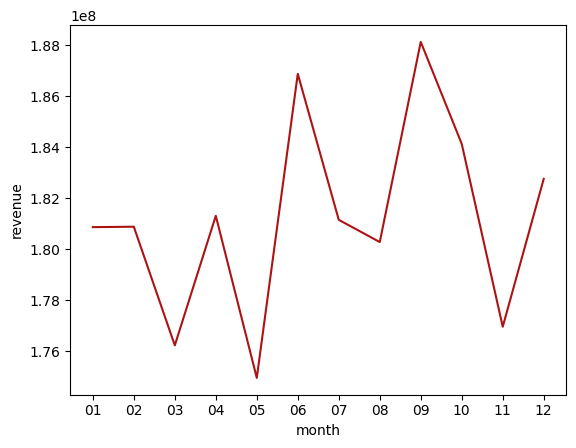

In [254]:
sns.lineplot(data=df.groupby("month")["revenue"].sum().reset_index(),x="month",y="revenue",color="#AD1313")

Text(0.5, 1.0, 'Pie chart by brand type')

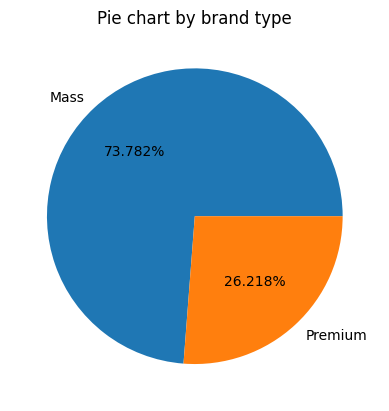

In [271]:
plt.pie(df.groupby("brand_type")["revenue"].sum(),labels=df.groupby("brand_type")["revenue"].sum().index,autopct="%0.3f%%")
plt.title("Pie chart by brand type")

In [266]:
df.columns

Index(['order_id', 'state', 'zone', 'category', 'brand_type',
       'customer_gender', 'customer_age', 'base_price', 'discount_percent',
       'final_price', 'units_sold', 'revenue', 'sales_event',
       'competition_intensity', 'inventory_pressure', 'datetime', 'year',
       'month', 'discount_amount', 'revenue_check', 'compare'],
      dtype='object')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Fashion'),
  Text(1, 0, 'Sports & Fitness'),
  Text(2, 0, 'Grocery Essentials'),
  Text(3, 0, 'Footwear'),
  Text(4, 0, 'Home & Living'),
  Text(5, 0, 'Beauty & Personal Care'),
  Text(6, 0, 'Electronics'),
  Text(7, 0, 'Premium Lifestyle')])

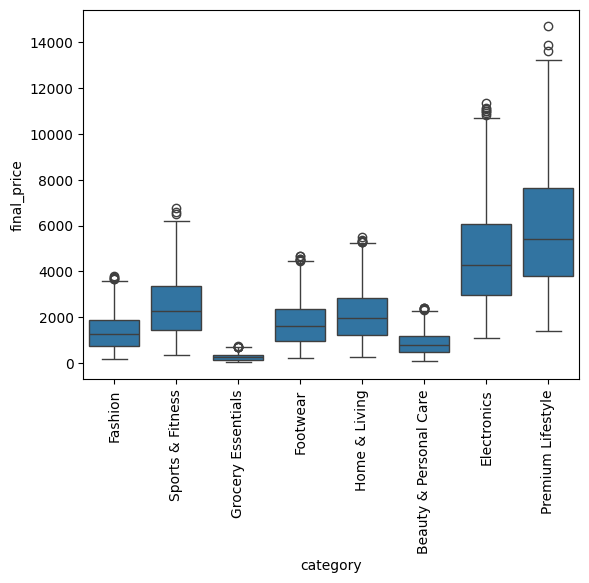

In [269]:
sns.boxplot(data=df,x="category",y="final_price")
plt.xticks(rotation=90)

<Axes: xlabel='customer_age', ylabel='Count'>

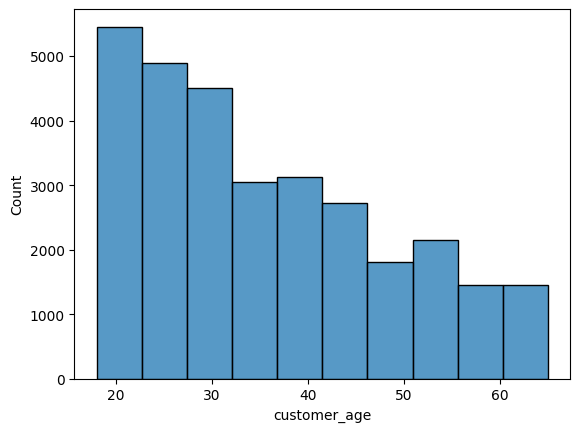

In [280]:
sns.histplot(data=df,x="customer_age",bins=10)

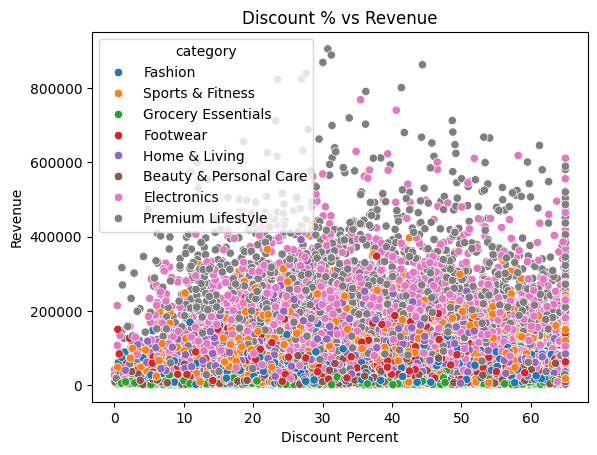

In [286]:
sns.scatterplot(x="discount_percent",y="revenue",data=df,hue="category")
plt.title("Discount % vs Revenue")
plt.xlabel("Discount Percent")
plt.ylabel("Revenue")
plt.show()